<a href="https://colab.research.google.com/github/EmilioUcelayLojo/AA3/blob/laboratorios_practicas/lab4/lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eirasf/GCED-AA3/blob/main/lab4/lab4.ipynb)

# Lab4: Aprendizaje por refuerzo - Programación dinámica

En este laboratorio nos familizarizaremos con [Gym](https://www.gymlibrary.dev/), una librería de Python para simular problemas que se pueden resolver utilizando aprendizaje por refuerzo.
Además, desarrollaremos algunos métodos de control basados en programación dinámica.

## Gym
Gym es una herramienta para desarrollar y comparar algoritmos de aprendizaje por refuerzo. Facilita la simulación de interacciones de un agente con entornos muy diversos.

Para utilizar OpenGym, el primer paso es importar la librería. Una vez hecho, podremos crear un entorno que nos permita simular el problema que deseemos de entre los muchos disponibles.

En esta práctica utilizaremos un entorno muy sencillo que simula un *GridWorld*, es decir, un mundo compuesto por casillas por las que el agente podrá desplazarse. En particular, cargaremos el entorno `MiniGrid-Empty-5x5-v0`.

In [19]:
# Si los paquetes no están instalados, hay que ejecutar estas líneas:
!pip install gymnasium[classic-control]
!pip install minigrid
import gymnasium as gym
import minigrid
import numpy as np
env = gym.make('MiniGrid-Empty-5x5-v0', render_mode='rgb_array')

El método `gym.make` devuelve un objeto de tipo entorno que nos ofrece, entre otros, los siguientes métodos y propiedades:
 - `reset`: Devuelve el entorno a su estado original
 - `actions`: Muestra una lista de las acciones disponibles
 - `max_steps`: Fija el número máximo de acciones que puede realizar el agente en cada episodio
 - `render`: Devuelve una imagen donde aparece representada la situación actual
 - `step(accion)`: Ejecuta una acción y actualiza el entorno en consecuencia

El objetivo del agente en este problema es alcanzar la meta, representada por una casilla verde. El agente aparece representado como una flecha roja que refleja su posición y orientación.

['left', 'right', 'forward', 'pickup', 'drop', 'toggle', 'done']


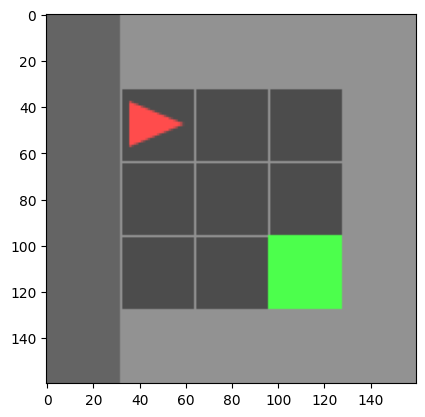

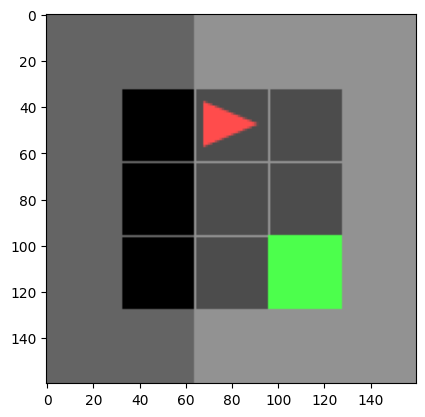

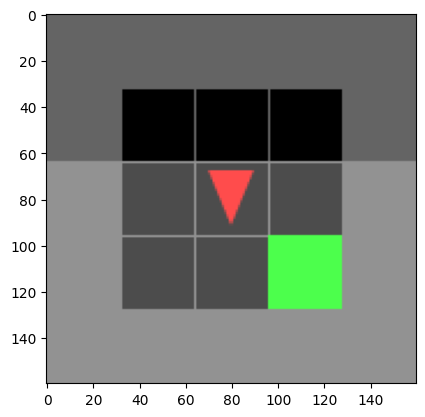

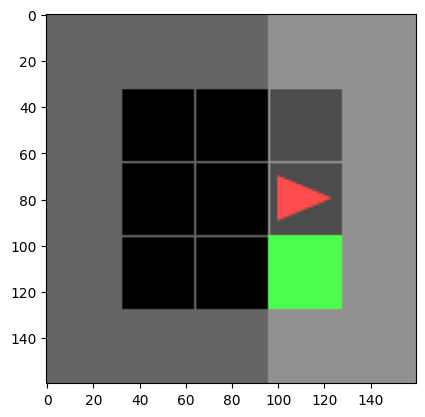

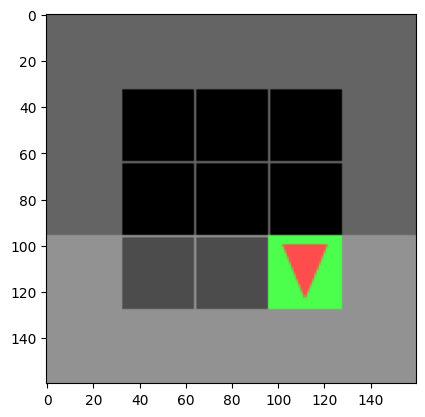

In [20]:
# Muestra las acciones disponibles
acciones = env.get_wrapper_attr('actions')
print([a.name for a in acciones])

# Resetea el entorno
env.reset()

# Muestra el entorno en su estado inicial
import matplotlib.pyplot as plt

def muestra_entorno(env:gym.Env) -> None:
    im = plt.imshow(env.render())
    plt.show()
muestra_entorno(env)

# TODO: Ejecuta la acción forward (puedes referirte a la acción i-ésima como acciones(i) o como acciones.nombre) y muestra el entorno de nuevo
env.step(acciones.forward)  # Ejecuta la acción 'forward'
muestra_entorno(env)       # Muestra el entorno después de la acción

# TODO: Prueba a ver cómo afectan las distintas acciones al entorno
env.step(acciones.right)   # Ejecuta la acción 'right'
env.step(acciones.forward)  # Ejecuta la acción 'forward'
muestra_entorno(env)       # Muestra el entorno

env.step(acciones.left)    # Ejecuta la acción 'left'
env.step(acciones.forward)  # Ejecuta la acción 'forward'
muestra_entorno(env)       # Muestra el entorno

env.step(acciones.right)    # Ejecuta la acción 'right'
env.step(acciones.forward)  # Ejecuta la acción 'forward'
muestra_entorno(env)


El método [`step(acción)`](https://gymnasium.farama.org/api/env/#gymnasium.Env.step) devuelve cinco valores:
 - Observación: Representa lo que puede percibir el agente del entorno en su estado actual
 - Recompensa: Indica el valor de la señal de recompensa para la ejecución de la acción aplicada en el estado en que se aplicó.
 - Terminated: Valor booleano que indica si se ha terminado el episodio
 - Truncated: Valor booleano que indica si el episodio ha alcanzado el número máximo de pasos
 - Info: Información adicional

De cara a aprender una política, debemos buscar una manera de representar los estados. Habitualmente, el agente se basaría en sus observaciones para generar una representación del estado. Sin embargo, para este problema en particular, vamos a utilizar una representación del estado más sencilla que la observación que puede hacer el agente. Esta labor de representación del estado la llevaría a cabo el **intérprete** en el esquema habitual de un problema de aprendizaje por refuerzo.
![Esquema de aprendizaje por refuerzo](https://github.com/eirasf/GCED-AA3/blob/main/lab4/img/Reinforcement_learning_diagram.svg?raw=1)

El intérprete identificará el estado con un vector de tres componentes que indicarán, respectivamente, la columna, fila y orientación del agente. Las filas/columnas se numerarán del 0 al 2 (de arriba a abajo y derecha a izquierda) y la orientación podrá tomar los siguientes valores:
 - 0 $\rightarrow$ derecha
 - 1 $\rightarrow$ abajo
 - 2 $\rightarrow$ izquierda
 - 3 $\rightarrow$ arriba

El entorno de este problema nos da acceso directo a dos variables que serán de utilidad:
 - `agent_pos`: Indica la casilla en la que está el agente. Las casillas del tablero están numeradas del 1 al 3, por lo que será necesario adaptar dicha numeración.
 - `agent_dir`: Indica la orientación del agente usando el código descrito en el párrafo anterior.

 Puedes acceder a estos valores como `env.get_wrapper_attr('agent_pos')` y `env.get_wrapper_attr('agent_dir')` respectivamente.
Creemos una función que haga las labores de intérprete y devuelva la codificación del estado actual del entorno:

In [32]:
from collections import namedtuple

# Representaremos los estados como tuplas con los siguientes campos con nombre:
#  - x: Representa la columna en que se encuentra el agente. La columna visitable más a la izquierda será la 0
#  - y: Representa la fila en que se encuentra el agente. La fila visitable más arriba será la 0
#  - dir: Representa la dirección en que apunta el agente. Respetaremos el código numérico indicado por agent_dir
Estado = namedtuple('Estado', ['x', 'y', 'dir'])

def get_estado(env:gym.Env) -> Estado:
    # TODO - Completa la función
    # Obtener la posición y dirección del agente
    pos = env.get_wrapper_attr('agent_pos')
    direccion = env.get_wrapper_attr('agent_dir')

    # Adaptar la posición a la numeración del enunciado (empezando en 0)
    x = pos[0] - 1
    y = pos[1] - 1

    # Crear y devolver el Estado
    return Estado(x, y, direccion)

env.reset()

# COMPROBACIÓN
estado_actual = get_estado(env)
print(estado_actual)
assert estado_actual.x == 0, f'El estado inmediatamente después de resetear debe indicar x=0 y el tuyo indica {estado_actual.x}'
assert estado_actual.y == 0, f'El estado inmediatamente después de resetear debe indicar y=0 y el tuyo indica {estado_actual.y}'
assert estado_actual.dir == 0, f'El estado inmediatamente después de resetear debe indicar dir=0 y el tuyo indica {estado_actual.dir}'

Estado(x=0, y=0, dir=0)


### Simulación de un episodio con política aleatoria

Ahora que sabemos manejar el entorno, vamos a probar qué tal funciona una política aleatoria.

Crea un bucle que simule un episodio completo siguiendo una política aleatoria, es decir, que aplique una acción aleatoria hasta que el entorno nos indique que el episodio ha acabado. Puedes obtener una acción aleatoria llamando a `env.action_space.sample()`.

Muestra el entorno tras aplicar cada acción. Además muestra un mensaje que indique:
 - Qué número de paso se ha ejecutado
 - El nombre de la acción aplicada
 - El estado resultante
 - La recompensa obtenida en ese paso
 - Si ha terminado la ejecución

Max steps modificado: inf


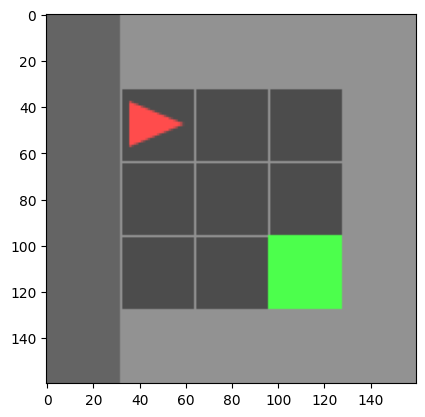

Paso 1:
  Acción: 5
  Estado: Estado(x=0, y=0, dir=0)
  Recompensa: 0
  ¿Terminado?: False
Paso 2:
  Acción: 0
  Estado: Estado(x=0, y=0, dir=3)
  Recompensa: 0
  ¿Terminado?: False
Paso 3:
  Acción: 5
  Estado: Estado(x=0, y=0, dir=3)
  Recompensa: 0
  ¿Terminado?: False
Paso 4:
  Acción: 2
  Estado: Estado(x=0, y=0, dir=3)
  Recompensa: 0
  ¿Terminado?: False
Paso 5:
  Acción: 5
  Estado: Estado(x=0, y=0, dir=3)
  Recompensa: 0
  ¿Terminado?: False
Paso 6:
  Acción: 3
  Estado: Estado(x=0, y=0, dir=3)
  Recompensa: 0
  ¿Terminado?: False
Paso 7:
  Acción: 1
  Estado: Estado(x=0, y=0, dir=0)
  Recompensa: 0
  ¿Terminado?: False
Paso 8:
  Acción: 0
  Estado: Estado(x=0, y=0, dir=3)
  Recompensa: 0
  ¿Terminado?: False
Paso 9:
  Acción: 4
  Estado: Estado(x=0, y=0, dir=3)
  Recompensa: 0
  ¿Terminado?: False
Paso 10:
  Acción: 2
  Estado: Estado(x=0, y=0, dir=3)
  Recompensa: 0
  ¿Terminado?: False
Paso 11:
  Acción: 0
  Estado: Estado(x=0, y=0, dir=2)
  Recompensa: 0
  ¿Terminado?: Fal

In [33]:
# Eliminamos el límite de pasos por episodio. Solo acabará el episodio al alcanzar la meta.
env.max_steps = float('inf')
print(f'Max steps modificado: {env.max_steps}')


completado = False
contador = 0
# Mostrar el entorno
env.reset()
muestra_entorno(env)

while not completado:
    # TODO - Completa el bucle
    # Obtener una acción aleatoria
    accion = env.action_space.sample()

    # Ejecutar la acción y obtener información del entorno
    observacion, recompensa, terminado, truncado, info = env.step(accion)

    # Mostrar información del paso
    contador += 1
    print(f'Paso {contador}:')
    print(f'  Acción: {accion}')
    print(f'  Estado: {get_estado(env)}')  # Usando la función get_estado
    print(f'  Recompensa: {recompensa}')
    print(f'  ¿Terminado?: {terminado}')

    # Actualizar la condición de finalización
    completado = terminado or truncado

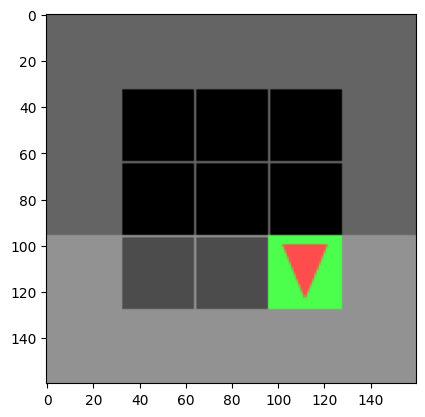

In [34]:
# Mostrar el entorno
muestra_entorno(env)

### Simplificación del espacio de acciones y definición de políticas
Habrás comprobado que hay acciones que no son útiles para este problema. Vamos a simplificar la búsqueda reduciendo el espacio de acciones a tres:
 1. left
 2. right
 3. forward

Al hacer esto, ya no podemos generar una acción aleatoria utilizando `env.action_space.sample()`. Además, dicha función elige una acción al azar, lo cual no nos interesa. Nuestro objetivo es obtener una **política** que determine la mejor acción en cada situación, así que vamos a aprovechar el momento para definir una estructura de datos que nos permita hacer eso.

La política debe indicar una probabilidad $\pi(a|s)$ de elegir la acción $a$ estando en el estado $s$ (así que $\sum_{a'}\pi(a'|s)=1$, con $s\in \mathcal{S}$ y $a\in \mathcal{A}$). Declararemos una política como un `numpy.array` que asocie a cada estado $s$ una distribución de probabilidad sobre las distintas acciones.

La política aleatoria otorgará la misma probabilidad a todas las acciones para cada estado (como hay tres acciones, para cualquier par estado-acción la probabilidad será 1/3).

In [47]:
# Seleccionamos solo las tres acciones indicadas
ACCIONES_UTILES = [acciones.left, acciones.right, acciones.forward]


# TODO - Indica el shape de la policy
politica_aleatoria = np.zeros((3, 3, 4, 3)) #3x3 dimension, 4 orientaciones y 3 acciones posibles
# Inicializamos todos los valores a 1/3
politica_aleatoria[:] = 1.0/3

Una vez hemos definido la política, podemos definir una función para sustituir a `env.action_space.sample()`. Esta función recibirá la política que debe seguir y el estado para el que seleccionar la acción. Devolverá la acción muestreada siguiendo la distribución descrita por la política para ese estado.

In [63]:
# Define el diccionario de mapeo
ACCIONES_MAPEO = {
    acciones.left: "left",
    acciones.right: "right",
    acciones.forward: "forward"
}

def muestrea_politica(estado:Estado, politica:np.ndarray) -> int:
    # Obtenemos la distribución de probabilidad
    probs = politica[estado.x, estado.y, estado.dir, :]
    # Comprobación de que la política está bien (se puede comentar cuando estemos seguros de que es así)
    np.testing.assert_almost_equal(np.sum(probs), 1.0, err_msg='La política para un estado siempre debe sumar 1')
    # Obtener la acción
    accion = np.random.choice(ACCIONES_UTILES, p=probs)

    return accion

# TODO - Obtén la acción muestreada de la policy_aleatoria para el estado en que el agente está en la casilla central mirando hacia abajo
accion = muestrea_politica(Estado(1, 1, 1), politica_aleatoria)

print(accion,'->', ACCIONES_MAPEO[accion])

2 -> forward


### Simulación de episodios siguiendo una política prefijada
Al disponer ya de una definición para políticas y de una función de muestreo sobre cualquier política, podemos adaptar nuestro bucle que simula un episodio para que lo haga siguiendo una política concreta.

Definiremos una función llamada `simula_episodio` para ello. La función debe recibir la política a seguir y dos parámetros que nos indicarán, respectivamente, si se mostrarán los *renders* de los pasos del episodio y si se mostrarán mensajes de texto.

La función deberá devolver una tupla con el **retorno** obtenido, es decir, la suma de las recompensas recibidas en cada paso y el **número de pasos** necesarios para completar el episodio.

In [69]:
def simula_episodio(politica:np.ndarray, muestra_renders:bool=False, imprime:bool=False) -> tuple[float, int]:
    env.reset()
    # muestra_entorno(env)
    # TODO - Adapta el bucle que escribiste 3 celdas de código más arriba para que use la política para decidir qué acción tomar en cada paso
    retorno = 0  # Inicializar el retorno a 0
    num_pasos = 0  # Inicializar el número de pasos a 0
    terminado = False  # Variable para controlar si el episodio ha terminado

    while not terminado:
        estado_actual = get_estado(env)  # Obtener el estado actual
        accion = muestrea_politica(estado_actual, politica)  # Obtener la acción según la política
        observacion, recompensa, terminado, truncado, info = env.step(accion)  # Ejecutar la acción

        retorno += recompensa  # Acumular la recompensa en el retorno
        num_pasos += 1  # Incrementar el contador de pasos

        if muestra_renders:
            muestra_entorno(env)  # Mostrar el render si se solicita

        if imprime:
            print(f"Paso: {num_pasos}, Acción: {ACCIONES_MAPEO[accion]}, Recompensa: {recompensa}, Terminado: {terminado}")

    return retorno, num_pasos  # Devolver el retorno y el número de pasos



# Simulamos un episodio
retorno, num_pasos = simula_episodio(politica_aleatoria, muestra_renders=False, imprime=True)
print(f'Simulado un episodio con retorno {retorno} ({num_pasos})')

#Mostramos el entorno al finalizar
# muestra_entorno(env)

Paso: 1, Acción: left, Recompensa: 0, Terminado: False
Paso: 2, Acción: forward, Recompensa: 0, Terminado: False
Paso: 3, Acción: right, Recompensa: 0, Terminado: False
Paso: 4, Acción: forward, Recompensa: 0, Terminado: False
Paso: 5, Acción: left, Recompensa: 0, Terminado: False
Paso: 6, Acción: forward, Recompensa: 0, Terminado: False
Paso: 7, Acción: forward, Recompensa: 0, Terminado: False
Paso: 8, Acción: left, Recompensa: 0, Terminado: False
Paso: 9, Acción: forward, Recompensa: 0, Terminado: False
Paso: 10, Acción: left, Recompensa: 0, Terminado: False
Paso: 11, Acción: forward, Recompensa: 0, Terminado: False
Paso: 12, Acción: right, Recompensa: 0, Terminado: False
Paso: 13, Acción: left, Recompensa: 0, Terminado: False
Paso: 14, Acción: right, Recompensa: 0, Terminado: False
Paso: 15, Acción: right, Recompensa: 0, Terminado: False
Paso: 16, Acción: forward, Recompensa: 0, Terminado: False
Paso: 17, Acción: forward, Recompensa: 0, Terminado: False
Paso: 18, Acción: forward, Re

### Comprobación del rendimiento de la política

Hagamos un experimento para evaluar la eficacia de la política aleatoria. Simularemos 200 episodios, anotando el número de pasos necesarios para completar cada uno. No es necesario que llevemos cuenta de los retornos obtenidos porque en este problema siempre será 1 (dado que solo la última acción da recompensa, con valor 1).

Mostraremos estadísticas y gráficos que nos puedan ayudar a tener una idea de cómo de bien funciona.

1 - Simulado un episodio con retorno -0.4849999999999999 (165)
2 - Simulado un episodio con retorno -0.08899999999999997 (121)
3 - Simulado un episodio con retorno 0.595 (45)
4 - Simulado un episodio con retorno 0.73 (30)
5 - Simulado un episodio con retorno 0.4959999999999999 (56)
6 - Simulado un episodio con retorno 0.6579999999999999 (38)
7 - Simulado un episodio con retorno 0.586 (46)
8 - Simulado un episodio con retorno 0.45999999999999996 (60)
9 - Simulado un episodio con retorno 0.514 (54)
10 - Simulado un episodio con retorno 0.73 (30)
11 - Simulado un episodio con retorno 0.73 (30)
12 - Simulado un episodio con retorno 0.766 (26)
13 - Simulado un episodio con retorno 0.892 (12)
14 - Simulado un episodio con retorno 0.685 (35)
15 - Simulado un episodio con retorno 0.847 (17)
16 - Simulado un episodio con retorno -0.9890000000000001 (221)
17 - Simulado un episodio con retorno 0.955 (5)
18 - Simulado un episodio con retorno 0.32499999999999996 (75)
19 - Simulado un episodio con r

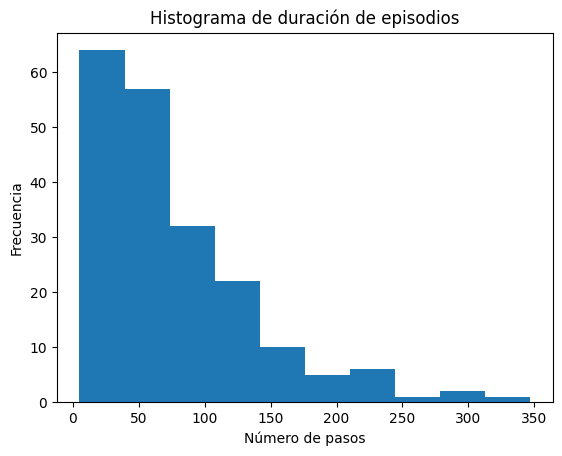

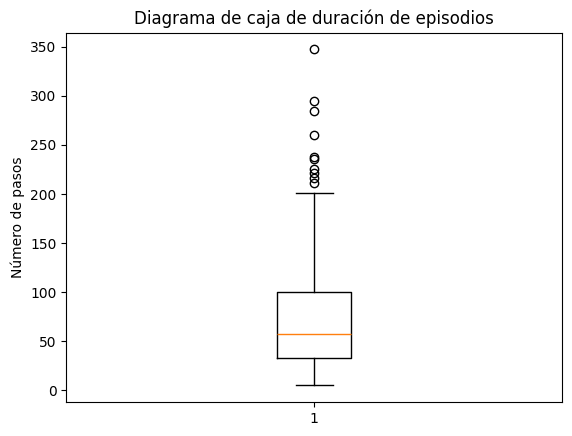

Se han necesitado de media 75.97 pasos (+- 60.88315941210673 )
El episodio más corto duró 5 pasos y el episodio más largo duró 347 pasos


In [70]:
def comprueba_politica(politica:np.ndarray) -> None:
    episodios_pasos = []

    # TODO - Simula 200 episodios, añadiendo sus respectivos números de pasos a episodios_pasos y mostrando por cada uno un mensaje de la forma '{iteracion} - Simulado un episodio con retorno {retorno} ({num_pasos})'
    for iteracion in range(200):
        retorno, num_pasos = simula_episodio(politica)  # Simular un episodio
        episodios_pasos.append(num_pasos)  # Guardar el número de pasos
        print(f'{iteracion + 1} - Simulado un episodio con retorno {retorno} ({num_pasos})')  # Mostrar el mensaje

    assert len(episodios_pasos) == 200  # Verificar que se simularon 200 episodios

    # Mostrar histograma
    plt.hist(episodios_pasos)
    plt.xlabel('Número de pasos')
    plt.ylabel('Frecuencia')
    plt.title('Histograma de duración de episodios')
    plt.show()

    # Mostrar diagrama de caja
    plt.boxplot(episodios_pasos)
    plt.ylabel('Número de pasos')
    plt.title('Diagrama de caja de duración de episodios')
    plt.show()

    # Mostrar estadísticas
    print('Se han necesitado de media', np.mean(episodios_pasos), 'pasos (+-', np.std(episodios_pasos), ')')
    print('El episodio más corto duró', np.min(episodios_pasos), 'pasos y el episodio más largo duró', np.max(episodios_pasos), 'pasos')


comprueba_politica(politica_aleatoria)

# Obtención de políticas óptimas
## Métodos de programación dinámica

A la hora de encontrar una política óptima que guíe las acciones de nuestro agente, los métodos basados en programación dinámica son una buena opción cuando disponemos de conocimento respecto a las dinámicas del entorno.

En particular, estos métodos requieren conocer $p(s',r | s,a)$, es decir, la probabilidad de acabar en un estado $s'$ recibiendo una recompensa $r$ si aplicamos la acción $a$ al estado $s$.

OpenGym no nos proporciona esta información, pero en este problema sencillo podemos reconstruirla. Este entorno es determinista, lo que quiere decir que si aplicamos la acción $a$ al estado $s$ siempre obtendremos el mismo estado $s'$ y la misma recompensa $r$ con probabilidad 1 (cualquier otro estado $s_j$ o recompensa $r_j$ tendrán $p(s_j,r_j|s,a)=0$).

Podemos, por tanto, representar el modelo con dos variables:
 - `modelo_transiciones`: Para cada combinación $s,a$, almacena el estado $s'$ al que conduce aplicar la acción $a$ a $s$.
 - `modelo_recompensas`: Para cada combinación $s,a$, almacena el valor de la recompensa obtenida al aplicar la acción $a$ a $s$.

Sabiendo cómo se comporta el entorno, definimos estas dos variables con los valores adecuados.

In [73]:
# DEFINICIÓN DEL MODELO

# Modelo de transiciones - Almacena a qué estado lleva aplicar cada acción a cada estado
# Lo almacenamos en un array numpy en el que para cada estado almacenemos, para cada acción, el estado al que lleva.
modelo_transiciones = np.zeros((3,3,4,3,3),dtype=np.int16)
# Recorremos cada estado para completar el estado al que lleva cada una de las tres acciones posibles
for i in range(3): # Columnas (x)
    for j in range(3): # Filas (y)
        for k in range(4): # Orientaciones (dir)
            # Aplicar la acción left gira el agente a la izquierda, así que el estado resultante tendrá el mismo valor para filas y columnas pero variará la orientación
            modelo_transiciones[i,j,k,0]=[i,j,(k+4-1)%4]
            # Aplicar la acción right gira el agente a la derecha, así que el estado resultante tendrá el mismo valor para filas y columnas pero variará la orientación
            modelo_transiciones[i,j,k,1]=[i,j,(k+1)%4]
        # Aplicar la acción forward mantiene la orientación, pero cambia filas o columnas en función de hacia dónde esté orientado
        if i<2:
            modelo_transiciones[i,j,0,2]=[i+1,j,0] # Derecha
        if j<2:
            modelo_transiciones[i,j,1,2]=[i,j+1,1] # Abajo
        if i>0:
            modelo_transiciones[i,j,2,2]=[i-1,j,2] # Izquierda
        if j>0:
            modelo_transiciones[i,j,3,2]=[i,j-1,3] # Arriba

# Modelo de transiciones - Almacena qué recompensa proporciona aplicar cada acción a cada estado
# Lo almacenamos en un array numpy en el que para cada estado almacenemos, para cada acción, la recompensa.
modelo_recompensas = np.zeros((3,3,4,3))
# Será 0 siempre menos en dos casos:
# 1 - Está en la segunda columna de la tercera fila, orientado a la derecha y se usa la acción forward
modelo_recompensas[1,2,0,2] = 1
# 2 - Está en la tercera columna de la segunda fila, orientado hacia abajo y se usa la acción forward
modelo_recompensas[2,1,1,2] = 1

# Función auxiliar para consultar los estados a los que lleva cada acción para un estado dado
def get_resultados_por_accion_en(estado: Estado) -> list[Estado]:
    valores_estados_para_cada_accion = modelo_transiciones[estado.x, estado.y, estado.dir]
    return list(map(lambda x: Estado(*x), valores_estados_para_cada_accion))

# Función auxiliar para consultar las recompensas de aplicar cada acción en un estado dado
def get_recompensas_por_accion_en(estado: Estado) -> np.ndarray:
    # TODO - Completa la función
    return modelo_recompensas[estado.x, estado.y, estado.dir]

# TODO - Muestra los estados resultantes y las recompensas de aplicar las distintas acciones cuando el agente está en la tercera casilla de la segunda fila, orientado hacia abajo y se ejecuta la acción forward
estado = Estado(2, 1, 1)  # Tercera casilla de la segunda fila, orientado hacia abajo
resultados = get_resultados_por_accion_en(estado)
recompensas = get_recompensas_por_accion_en(estado)

print("Estados resultantes:")
for i, resultado in enumerate(resultados):
    print(f"Acción {i}: {resultado}")

print("\nRecompensas:")
for i, recompensa in enumerate(recompensas):
    print(f"Acción {i}: {recompensa}")

Estados resultantes:
Acción 0: Estado(x=2, y=1, dir=0)
Acción 1: Estado(x=2, y=1, dir=2)
Acción 2: Estado(x=2, y=2, dir=1)

Recompensas:
Acción 0: 0.0
Acción 1: 0.0
Acción 2: 1.0


## Algoritmo 1: Evaluación de políticas iterativa
El algoritmo de evaluación de políticas iterativa calcula el valor $v_\pi(s)$ para todo estado $s$ siguiendo la política $\pi$. La fórmula que utiliza, que está basada en la ecuación de Bellman para $v_\pi(s)$, es esta:

$$v_\pi(s)=\mathbb{E}_\pi [R_{t+1}+\gamma v_k(S_{t+1}) | S_t=s]$$

$$=\sum_a\pi(a|s)\sum_{s',r}p(s',r|s,a)[r+\gamma v_k(s')]$$

Al ser este un problema determinista, la expresión se simplifica, dado que $p(s',r|s,a)$ será 0 en todos los casos menos en 1 (porque aplicar la acción $a$ al estado $s$ conduce siempre a un estado $s'$ fijo y único y otorga siempre una recompensa $r$ fija y única; ambos valores los podemos obtener del modelo).

Puedes ver el algoritmo al completo aquí (y un ejemplo en la transparencia 19 del Tema 3 de teoría):
![Evaluación de políticas iterativa](https://github.com/eirasf/GCED-AA3/blob/main/lab4/img/iterative-policy-evaluation.png?raw=1)

Implementemos el algoritmo para obtener los valores asignados a cada estado siguiendo una política fija.

**CONSEJO: Para asegurar la convergencia, actualiza todos los valores de $V_{t+1}(s)$ a partir de los valores $V_t(s)$, es decir, crea una variable `nuevos_valores_estados` donde almacenes todos los calculados en una iteración y al completar la iteración establece `valores_estados = nuevos_valores_estados`**

In [80]:
GAMMA = 0.1

def iterative_policy_evaluation(politica: np.ndarray) ->np.ndarray:
    THETA = 0.00001

    # En esta variable almacenaremos los valores calculados para los estados
    # TODO - Indica el shape adecuado. Debes almacenar un valor por cada estado posible
    valores_estados = np.zeros((3, 3, 4))  # Shape: (x, y, dir)

    # TODO - Completa el algoritmo según lo descrito arriba
    while True:
        delta = 0
        # Crear una copia para almacenar los nuevos valores de estado
        nuevos_valores_estados = np.copy(valores_estados)

        # Recorrer todos los estados posibles
        for x in range(3):
            for y in range(3):
                for dir in range(4): #Loop for each s

                    v = valores_estados[x, y, dir]  # Valor actual del estado

                    # Calcular el nuevo valor del estado
                    nuevo_v = 0
                    for accion_index, accion in enumerate(ACCIONES_UTILES):
                        # Obtener el estado siguiente y la recompensa para esta acción
                        estado_siguiente = get_resultados_por_accion_en(Estado(x, y, dir))[accion_index]
                        recompensa = get_recompensas_por_accion_en(Estado(x, y, dir))[accion_index]

                        # Actualizar el nuevo valor del estado usando la ecuación de Bellman
                        nuevo_v += politica[x, y, dir, accion_index] * (recompensa + GAMMA * valores_estados[estado_siguiente.x, estado_siguiente.y, estado_siguiente.dir])

                     # Almacenar el nuevo valor en la copia
                    nuevos_valores_estados[x, y, dir] = nuevo_v
                    delta = max(delta, abs(v - nuevo_v))  # Actualizar delta

        # Actualizar valores_estados con los nuevos valores
        valores_estados = nuevos_valores_estados

        # Si delta es menor que THETA, detener la iteración
        if delta < THETA:
            break

    return valores_estados

valores_estados = iterative_policy_evaluation(politica_aleatoria)
print(valores_estados)

# COMPROBACIÓN
np.testing.assert_almost_equal(valores_estados[0,0,1], 4.11522634e-07)

[[[4.11522634e-07 4.11522634e-07 0.00000000e+00 0.00000000e+00]
  [1.31687243e-05 1.27572016e-05 4.11522634e-07 4.11522634e-07]
  [1.11604938e-02 3.72839506e-04 2.46913580e-05 3.72839506e-04]]

 [[1.27572016e-05 1.31687243e-05 4.11522634e-07 4.11522634e-07]
  [3.85185185e-04 3.85185185e-04 1.31687243e-05 1.31687243e-05]
  [3.34077366e-01 1.11604938e-02 7.44855967e-04 1.11609053e-02]]

 [[3.72839506e-04 1.11604938e-02 3.72839506e-04 2.46913580e-05]
  [1.11604938e-02 3.34077366e-01 1.11609053e-02 7.44855967e-04]
  [8.23045267e-07 8.23045267e-07 2.55144033e-05 2.55144033e-05]]]


### Optimización de políticas

En el apartado anterior hemos obtenido un valor para cada estado del problema cuando se sigue la política $\pi$. Según lo visto en teoría, podemos utilizar estos valores para encontrar una nueva política $\pi'$ que sea igual o mejor que $\pi$.

Cuando disponemos de $v_\pi(s)$ y del modelo que describe el funcionamiento del entorno, podemos obtener una política $\pi'\geq\pi$ simplemente seleccionando, para cada estado, la acción que nos da un mayor retorno, que podemos calcular como la recompensa inmediata más el valor del estado al que llegamos (descontado por $\gamma$).

$$\pi'(s)=\arg\max_a\sum_{s',r}p(s',r|s,a)\left[r+\gamma v_\pi(s')\right]$$

Escribamos un algoritmo que obtenga $\pi'$ a partir de `state_values`.

In [82]:
def crea_politica_avara(valores_estados: np.ndarray) -> np.ndarray:
    nueva_shape = list(valores_estados.shape)
    nueva_shape.append(3)
    # TODO - Indica la shape apropiada. Por cada par estado-acción debemos almacenar la probabilidad que da esta política de tomar esa acción estando en dicho estado
    # Como la política es determinista, para un estado concreto todas las acciones tendrán probabilidad 0 menos una que tendrá probabilidad 1
    politica = np.zeros((3, 3, 4, 3))
    # TODO - Haz bucles anidados para recorrer todos los estados
    for x in range(3):
        for y in range(3):
            for dir in range(4):
                # Ahora para este estado debemos calcular, para todas las acciones a, G=(r + GAMMA*state_values[s[0],s[1],s[2]]) donde r es la recompensa de aplicar a y s es el estado resultante.
                # De todos esos valores, tomaremos el mejor (supongamos que es el i-ésimo) y pondremos probabilidad 1 en la acción i-ésima para dicho estado.
                # TODO - Recorre las acciones, calculando su G. Selecciona el mejor y pon a 1 la probabilidad de la acción correspondiente.
                # Calcular el valor de cada acción en el estado actual
                valores_acciones = []
                for accion_index, accion in enumerate(ACCIONES_UTILES):
                    estado_siguiente = get_resultados_por_accion_en(Estado(x, y, dir))[accion_index]
                    recompensa = get_recompensas_por_accion_en(Estado(x, y, dir))[accion_index]
                    valor_accion = recompensa + GAMMA * valores_estados[estado_siguiente.x, estado_siguiente.y, estado_siguiente.dir]
                    valores_acciones.append(valor_accion)

                # Encontrar la acción con el mayor valor
                mejor_accion_index = np.argmax(valores_acciones)

                # Asignar probabilidad 1 a la mejor acción y 0 al resto
                politica[x, y, dir] = 0  # Inicializar a 0
                politica[x, y, dir, mejor_accion_index] = 1  # Asignar 1 a la mejor acción

    return politica

politica_mejorada = crea_politica_avara(valores_estados)

# COMPROBACIÓN
assert(np.array_equal(politica_mejorada[2,1,1],[0., 0., 1.]))

print(politica_mejorada[2,1,1])

[0. 0. 1.]


## Obtención de la política óptima - Policy iteration
Ahora que podemos evaluar una política y, a partir de esos valores, obtener una política mejorada, podemos repetir el proceso para seguir mejorando nuestra política hasta que no cambie. Este procedimiento se denomina *policy iteration* y lo tienes aquí descrito:

![Policy iteration](https://github.com/eirasf/GCED-AA3/blob/main/lab4/img/policy-iteration.png?raw=1)

Implementémoslo (la mayoría ya lo tenemos hecho).

In [83]:
def policy_iteration(politica_inicial: np.ndarray) -> np.ndarray:
    politica_actual = politica_inicial
    politica_estable = False
    # Llevaremos cuenta del paso en que estamos
    paso = 0

    while not politica_estable:
        # TODO - Calcula los valores para current_policy
        # 1. Evaluación de la política
        valores_actuales = iterative_policy_evaluation(politica_actual)

        # TODO - Obtén la nueva política mejorada a partir de los valores calculados
        # 2. Mejora de la política
        nueva_politica = crea_politica_avara(valores_actuales)

        # Comprobamos si la política ha cambiado
        politica_estable = np.array_equal(politica_actual, nueva_politica)

        # Preparamos la siguiente iteración
        politica_actual = nueva_politica
        paso+=1
        print('Paso #',paso)

    # Al terminar el bucle habremos obtenido una política que ya no mejora
    return politica_actual

politica_optima = policy_iteration(politica_aleatoria)
print(politica_optima)

# COMPROBACIÓN
assert(np.array_equal(politica_optima[2,0,1], [0., 0., 1.]))

Paso # 1
Paso # 2
Paso # 3
[[[[0. 0. 1.]
   [0. 0. 1.]
   [1. 0. 0.]
   [0. 1. 0.]]

  [[0. 0. 1.]
   [0. 0. 1.]
   [1. 0. 0.]
   [0. 1. 0.]]

  [[0. 0. 1.]
   [1. 0. 0.]
   [1. 0. 0.]
   [0. 1. 0.]]]


 [[[0. 0. 1.]
   [0. 0. 1.]
   [1. 0. 0.]
   [0. 1. 0.]]

  [[0. 0. 1.]
   [0. 0. 1.]
   [1. 0. 0.]
   [0. 1. 0.]]

  [[0. 0. 1.]
   [1. 0. 0.]
   [1. 0. 0.]
   [0. 1. 0.]]]


 [[[0. 1. 0.]
   [0. 0. 1.]
   [1. 0. 0.]
   [1. 0. 0.]]

  [[0. 1. 0.]
   [0. 0. 1.]
   [1. 0. 0.]
   [1. 0. 0.]]

  [[1. 0. 0.]
   [0. 1. 0.]
   [0. 0. 1.]
   [0. 0. 1.]]]]


Comprobemos que la política obtenida funciona bien simulando un episodio siguiéndola.

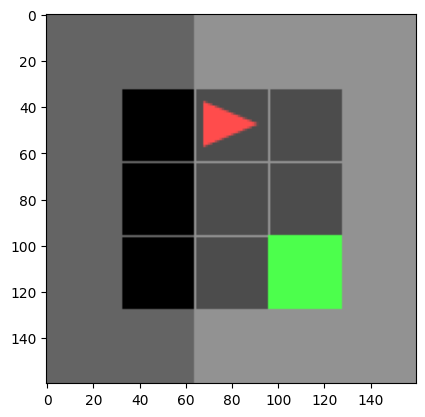

Paso: 1, Acción: forward, Recompensa: 0, Terminado: False


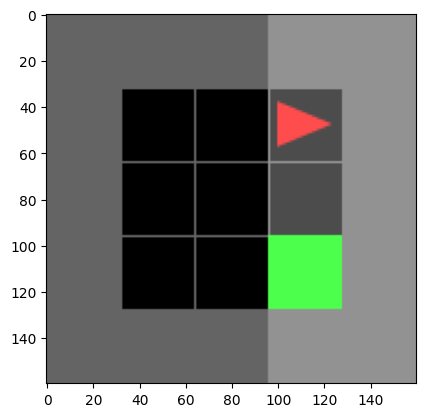

Paso: 2, Acción: forward, Recompensa: 0, Terminado: False


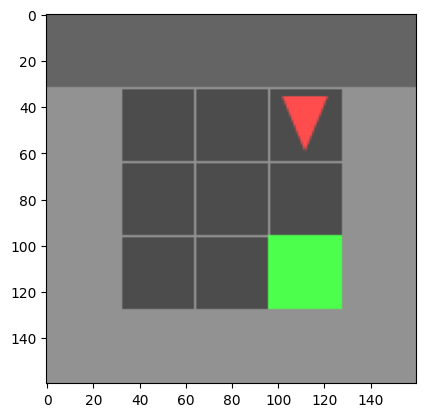

Paso: 3, Acción: right, Recompensa: 0, Terminado: False


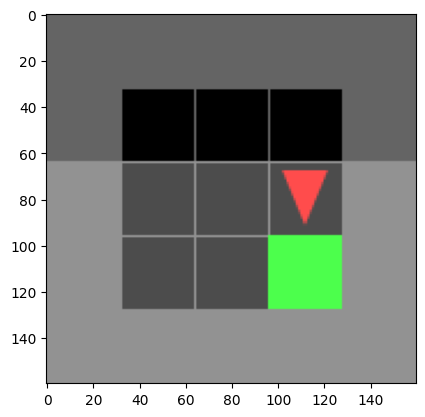

Paso: 4, Acción: forward, Recompensa: 0, Terminado: False


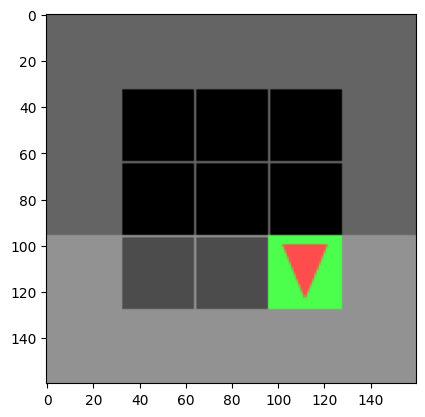

Paso: 5, Acción: forward, Recompensa: 0.955, Terminado: True


(0.955, 5)

In [84]:
simula_episodio(politica_optima, muestra_renders=True, imprime=True)

## Obtención de la política óptima - Iteración de valores
El proceso de iteración de políticas es costoso porque requiere hacer una estimación iterativa de $v_\pi(s)$ para todas las políticas por las que se pasa. Este proceso se puede simplificar y obtener una política óptima siguiendo el algoritmo de iteración de valores:

![Value iteration](https://github.com/eirasf/GCED-AA3/blob/main/lab4/img/value-iteration.png?raw=1)

El algoritmo es muy similar al de evaluación de políticas iterativas. La diferencia es que, en lugar de calcular $\mathbb{E}_\pi [R_{t+1}+\gamma v_k(S_{t+1}) | S_t=s]$, se toma el valor de la mejor acción. Al final, se devuelve la política greedy derivada de los valores calculados. Implementémoslo.

In [88]:
def value_iteration() -> np.ndarray: # No recibe ningún parámetro. Calcula valores y política a partir del modelo del entorno.
    # TODO - Repite el algoritmo de evaluación de políticas iterativa pero tomando el G de la mejor acción para cada estado
    # Una vez tengas los state_values, devuelve la política derivada de ellos
    THETA = 0.00001
    valores_estados = np.zeros((3, 3, 4))  # Inicializar valores de estado a 0

    while True:
        delta = 0
        for x in range(3):
            for y in range(3):
                for dir in range(4):
                    v = valores_estados[x, y, dir]

                    # Calcular el valor de cada acción y tomar el máximo
                    valores_acciones = []
                    for accion_index, accion in enumerate(ACCIONES_UTILES):
                        estado_siguiente = get_resultados_por_accion_en(Estado(x, y, dir))[accion_index]
                        recompensa = get_recompensas_por_accion_en(Estado(x, y, dir))[accion_index]
                        valor_accion = recompensa + GAMMA * valores_estados[estado_siguiente.x, estado_siguiente.y, estado_siguiente.dir]
                        valores_acciones.append(valor_accion)

                    valores_estados[x, y, dir] = max(valores_acciones)  # Actualizar con el máximo
                    delta = max(delta, abs(v - valores_estados[x, y, dir]))

        if delta < THETA:
            break
    # Obtener la política óptima a partir de los valores de estado
    politica_optima = crea_politica_avara(valores_estados)
    return politica_optima

otra_optima = value_iteration()
print(otra_optima)

# COMPROBACIÓN
assert(np.array_equal(otra_optima[2,0,1], [0., 0., 1.]))

[[[[0. 0. 1.]
   [0. 0. 1.]
   [1. 0. 0.]
   [0. 1. 0.]]

  [[0. 0. 1.]
   [0. 0. 1.]
   [1. 0. 0.]
   [0. 1. 0.]]

  [[0. 0. 1.]
   [1. 0. 0.]
   [1. 0. 0.]
   [0. 1. 0.]]]


 [[[0. 0. 1.]
   [0. 0. 1.]
   [1. 0. 0.]
   [0. 1. 0.]]

  [[0. 0. 1.]
   [0. 0. 1.]
   [1. 0. 0.]
   [0. 1. 0.]]

  [[0. 0. 1.]
   [1. 0. 0.]
   [1. 0. 0.]
   [0. 1. 0.]]]


 [[[0. 1. 0.]
   [0. 0. 1.]
   [1. 0. 0.]
   [1. 0. 0.]]

  [[0. 1. 0.]
   [0. 0. 1.]
   [1. 0. 0.]
   [1. 0. 0.]]

  [[1. 0. 0.]
   [0. 1. 0.]
   [0. 0. 1.]
   [0. 0. 1.]]]]


Para terminar, comprobemos que la política obtenida así también funciona bien.

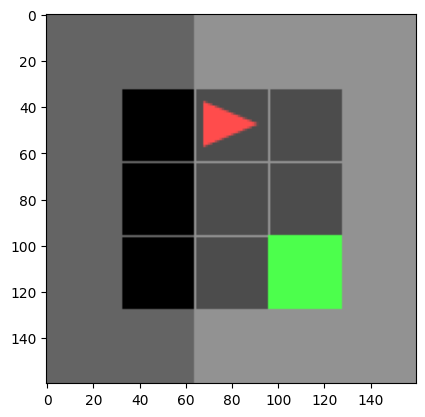

Paso: 1, Acción: forward, Recompensa: 0, Terminado: False


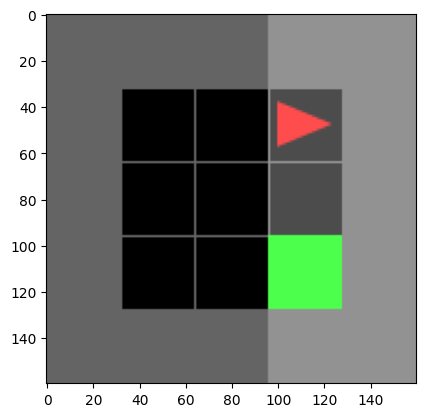

Paso: 2, Acción: forward, Recompensa: 0, Terminado: False


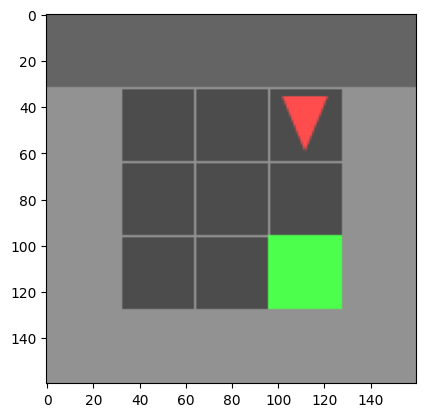

Paso: 3, Acción: right, Recompensa: 0, Terminado: False


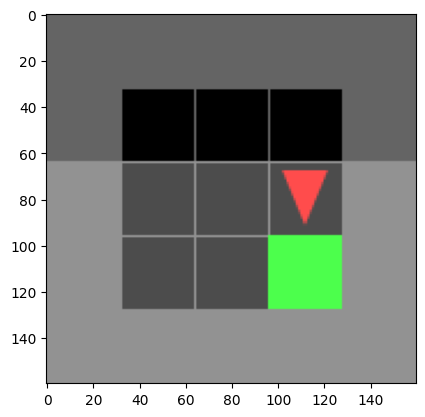

Paso: 4, Acción: forward, Recompensa: 0, Terminado: False


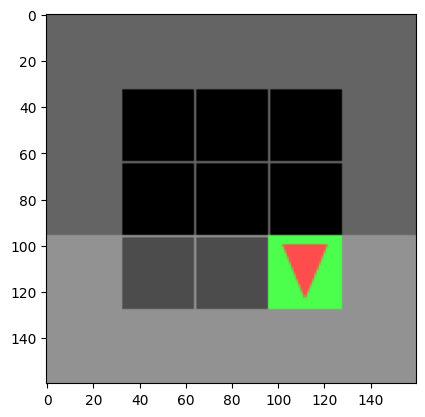

Paso: 5, Acción: forward, Recompensa: 0.955, Terminado: True


In [89]:
simula_episodio(otra_optima, muestra_renders=True, imprime=True)
env.close() # Cerramos, además, el entorno

# ¡Enhorabuena!
Has terminado este laboratorio. Ahora sabes cómo interactuar con OpenGym y cómo funcionan los principales algoritmos de programación dinámica para aprendizaje por refuerzo.